Code for CAISO data downloading (e.g. LMP, AS) from OASIS
https://opensource.gridstatus.io/en/latest/autoapi/gridstatus/caiso/index.html#gridstatus.caiso.CAISO.get_as_prices"

Author Yizhan Gu
Email: yig031@ucsd.edu

In [3]:
# NOTE: Use .conda environment!
import numpy as np
import calendar
from datetime import datetime
from datetime import timedelta
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

# import plotly.express as px
import matplotlib
import matplotlib.dates as mdates
import warnings
import os
import sys
warnings.filterwarnings("ignore")
from caiso import CAISO
iso = CAISO()

year = 2025
markets = ["DAM", 'RTM']
# Incrementally download missing Aug-Dec 2025 data and merge with existing Jun-Jul files.
download_start = f"Aug 1, {year}"
download_end = f"Dec 1, {year}"

In [4]:
# Download AS prices for each market
for market in markets:
    print(f"Downloading AS prices for {market} in {year}: {download_start} to {download_end}...")
    
    # Download missing Aug-Dec ancillary service prices, then merge with existing raw data.
    if market == 'DAM':
        df_new = iso.get_as_prices(start=download_start, end=download_end, market=market)
    elif market == 'RTM':
        df_new = iso.get_interval_as_prices(start=download_start, end=download_end, market=market)
        
    output_dir = f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}'
    os.makedirs(output_dir, exist_ok=True)
    output_file = f'{output_dir}/AS_price_{year}.csv'

    if os.path.exists(output_file):
        df_old = pd.read_csv(output_file)
        df = pd.concat([df_old, df_new], ignore_index=True)
        subset_cols = [c for c in ['Time', 'Interval Start', 'Interval End', 'Region', 'Market', 'Product'] if c in df.columns]
        if subset_cols:
            df = df.drop_duplicates(subset=subset_cols, keep='last')
        else:
            df = df.drop_duplicates(keep='last')
    else:
        df = df_new.copy()

    # Normalize time-like columns after merging old CSV strings with newly downloaded Timestamps.
    for _time_col in ['Time', 'Interval Start', 'Interval End']:
        if _time_col in df.columns:
            df[_time_col] = pd.to_datetime(df[_time_col], errors='coerce')

    if 'Time' in df.columns:
        df = df.sort_values('Time')

    # Save timezone-aware timestamps in a stable text format for later notebook runs.
    for _time_col in ['Time', 'Interval Start', 'Interval End']:
        if _time_col in df.columns:
            df[_time_col] = df[_time_col].astype(str)

    df.to_csv(output_file, index=False)
    print(f"Saved merged AS raw data: {output_file} ({len(df)} rows)")


  0%|          | 0/122 [00:00<?, ?it/s]2026-07-04 00:22:59 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_AS', 'version': 12}, 'params': {'market_run_id': ['DAM', 'HASP'], 'anc_type': ['ALL', 'NR', 'RD', 'RMD', 'RMU', 'RU', 'SR'], 'anc_region': ['ALL', 'AS_CAISO', 'AS_SP26_EXP', 'AS_SP26', 'AS_CAISO_EXP', 'AS_NP26_EXP', 'AS_NP26']}}
2026-07-04 00:22:59 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_AS&version=12&market_run_id=DAM&anc_type=ALL&anc_region=ALL&startdatetime=20250801T07:00-0000&enddatetime=20250802T07:00-0000
2026-07-04 00:23:00 - DEBUG - Found 1 files: ['20250801_20250801_PRC_AS_DAM_v12.csv']
2026-07-04 00:23:00 - DEBUG - Parsing file: 20250801_20250801_PRC_AS_DAM_v12.csv
  1%|          | 1/122 [00:04<08:54,  4.42s/it]2026-07-04 00:23:04 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_AS', 'version': 12}, 'params': {'market_run_id':

Saved merged AS raw data: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_DAM/AS_price_2025.csv (26358 rows)


  0%|          | 0/2929 [00:00<?, ?it/s]2026-07-04 00:38:03 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_AS', 'version': 1}, 'params': {'market_run_id': ['RTM'], 'anc_type': ['ALL', 'NR', 'RD', 'RMD', 'RMU', 'RU', 'SR'], 'anc_region': ['ALL', 'AS_CAISO', 'AS_SP26_EXP', 'AS_SP26', 'AS_CAISO_EXP', 'AS_NP26_EXP', 'AS_NP26']}}
2026-07-04 00:38:03 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_INTVL_AS&version=1&market_run_id=RTM&anc_type=ALL&anc_region=ALL&startdatetime=20250801T07:00-0000&enddatetime=20250801T08:00-0000
2026-07-04 00:38:03 - DEBUG - Found 1 files: ['20250801_20250801_PRC_INTVL_AS_RTM_01_v1.csv']
2026-07-04 00:38:03 - DEBUG - Parsing file: 20250801_20250801_PRC_INTVL_AS_RTM_01_v1.csv
  0%|          | 1/2929 [00:10<8:25:08, 10.35s/it]2026-07-04 00:38:13 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_INTVL_AS', 'version': 1}, 

Saved merged AS raw data: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_RTM/AS_price_2025.csv (105432 rows)


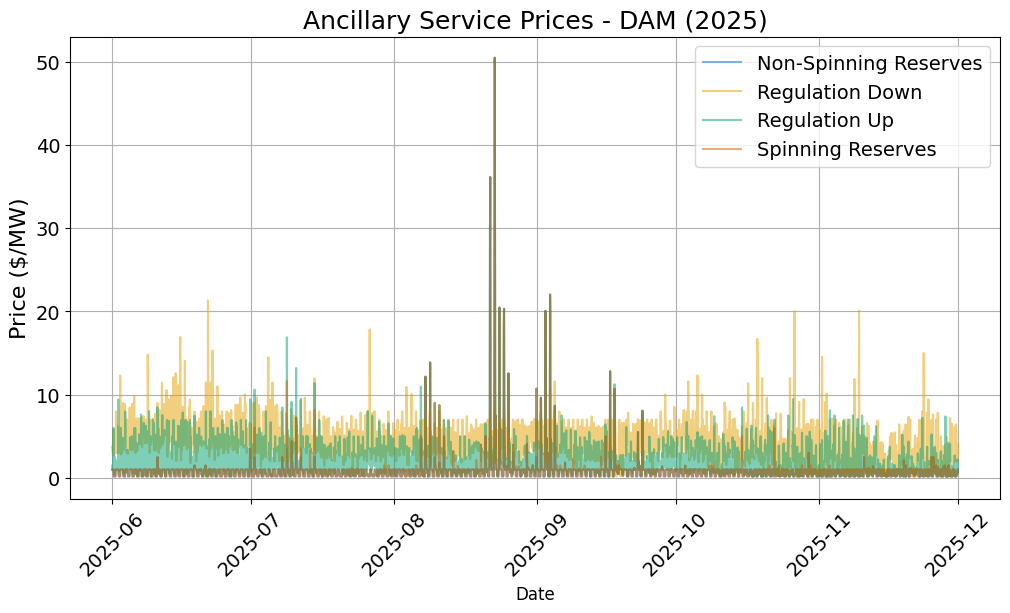

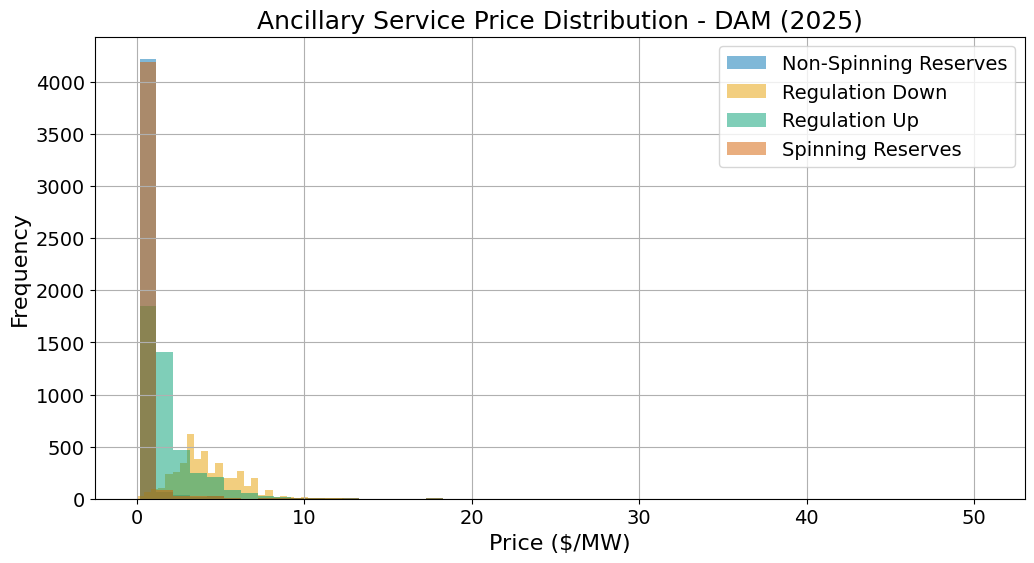

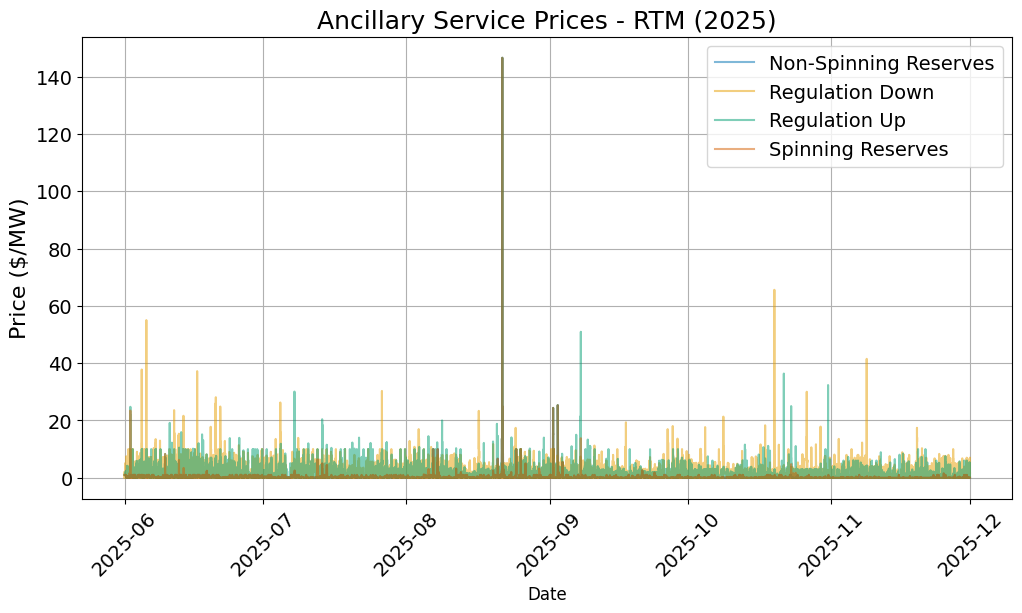

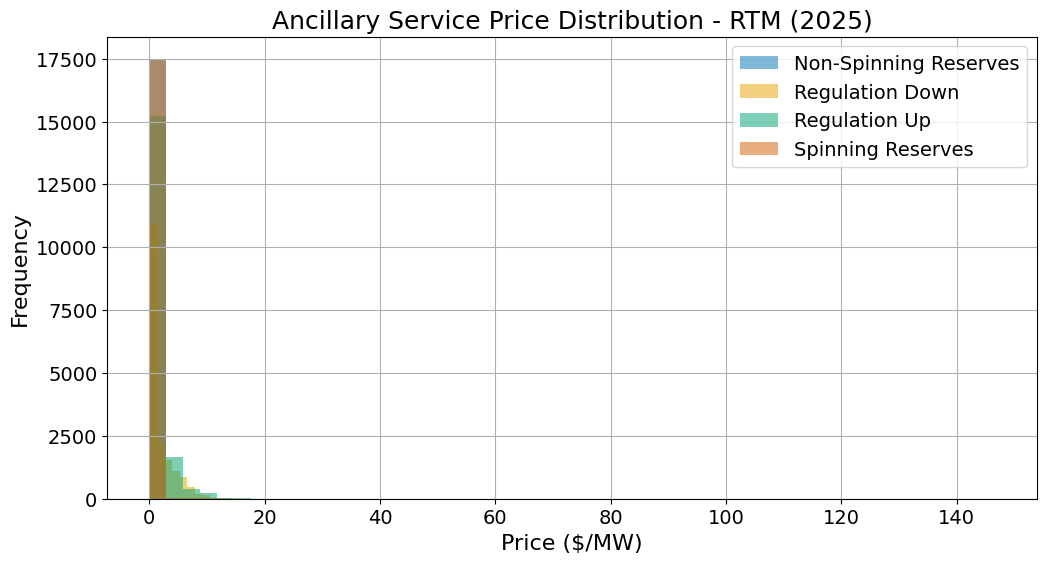

In [5]:
# Read and process the downloaded data
for market in markets:

    df_all = pd.read_csv(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}.csv')
    df = df_all[(df_all["Region"] == "AS_CAISO_EXP") & (df_all["Market"] == market)]
    # df = df_all[(df_all["Region"] == "AS_CAISO") & (df_all["Market"] == market)]


    df['Time'] = pd.to_datetime(df['Time'], utc=True)
    # NOTE: time from utc to local timezone
    df['datetime'] = df['Time'].dt.tz_convert('America/Los_Angeles')
    df.drop(columns=['Time', 'Interval Start', 'Interval End'], inplace=True)
    df = df.groupby(['datetime']).agg({
        'Non-Spinning Reserves': 'sum',
        'Regulation Down': 'sum',
        'Regulation Mileage Down': 'sum',
        'Regulation Mileage Up': 'sum',
        'Regulation Up': 'sum',
        'Spinning Reserves': 'sum'}).reset_index()
    df.rename(columns={
        'Non-Spinning Reserves': 'NonSpin',
        'Regulation Down': 'RegDown',
        'Regulation Mileage Down': 'RegDownMileage',
        'Regulation Mileage Up': 'RegUpMileage',
        'Regulation Up': 'RegUp',
        'Spinning Reserves': 'Spin'
    }, inplace=True)

    df.to_csv('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{}/AS_price_{}_clear.csv'.format(market, year), index=False)
    
    # Use a colorblind-friendly palette
    colors = {
        'NonSpin': '#0072B2',    # Blue
        'RegDown': '#E69F00',    # Orange
        'RegUp': '#009E73',      # Green
        'Spin': '#D55E00',       # Vermillion
    }

    # Update plot colors
    plt.figure(figsize=(12, 6))
    plt.plot(df['datetime'], df['NonSpin'], label='Non-Spinning Reserves', color=colors['NonSpin'], alpha=0.5)
    plt.plot(df['datetime'], df['RegDown'], label='Regulation Down', color=colors['RegDown'], alpha=0.5)
    plt.plot(df['datetime'], df['RegUp'], label='Regulation Up', color=colors['RegUp'], alpha=0.5)
    plt.plot(df['datetime'], df['Spin'], label='Spinning Reserves', color=colors['Spin'], alpha=0.5)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($/MW)', fontsize=16)
    plt.title(f'Ancillary Service Prices - {market} ({year})', fontsize=18)
    plt.legend(fontsize=14)
    plt.grid()
    plt.xticks(fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(fontsize=14)
    # plt.ylim(0, 20)
    plt.savefig(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Histogram with colorblind-friendly palette
    plt.figure(figsize=(12, 6))
    plt.hist(df['NonSpin'], bins=50, alpha=0.5, label='Non-Spinning Reserves', color=colors['NonSpin'])
    plt.hist(df['RegDown'], bins=50, alpha=0.5, label='Regulation Down', color=colors['RegDown'])
    plt.hist(df['RegUp'], bins=50, alpha=0.5, label='Regulation Up', color=colors['RegUp'])
    plt.hist(df['Spin'], bins=50, alpha=0.5, label='Spinning Reserves', color=colors['Spin'])
    plt.xlabel('Price ($/MW)', fontsize=16)
    plt.ylabel('Frequency', fontsize=16)
    plt.title(f'Ancillary Service Price Distribution - {market} ({year})', fontsize=18)
    plt.legend(fontsize=14)
    # plt.xlim(0, 15)
    plt.grid()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.savefig(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


In [6]:
# Summary statistics
for market in markets:
    df = pd.read_csv(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_clear.csv')
    stats = df.describe()
    print(f"Summary statistics for {market} in {year}:")
    print(stats.to_string(line_width=10**7))
    stats.to_csv(f'/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/2025Data/AS_{market}/AS_price_{year}_stats.csv', index=True)
    print("\n")

Summary statistics for DAM in 2025:
           NonSpin      RegDown  RegDownMileage  RegUpMileage        RegUp         Spin
count  4393.000000  4393.000000     4393.000000   4393.000000  4393.000000  4393.000000
mean      0.781290     4.216086        0.000381      0.000153     1.959287     0.800521
std       1.676587     2.016400        0.003020      0.001910     2.133460     1.713659
min       0.170000     0.010000        0.000000      0.000000     0.170000     0.170000
25%       0.170000     2.960000        0.000000      0.000000     0.998880     0.170000
50%       0.610000     3.963310        0.000000      0.000000     1.478340     0.610000
75%       1.000000     5.425450        0.000000      0.000000     2.252270     1.000000
max      50.500700    21.338230        0.100000      0.100000    50.500700    50.500700


Summary statistics for RTM in 2025:
            NonSpin       RegDown  RegDownMileage  RegUpMileage         RegUp          Spin
count  17572.000000  17572.000000    17572